# Part 2 — Feature Engineering

> **Note:** This stage prepares the model-ready feature matrix by combining sentiment, macroeconomic, FX, and bond-yield signals. If you later switch fully to real downloaded inputs, this is the section to update first.

### Notebook 02 — Feature Engineering
### Sovereign Credit Rating Prediction | George Nyatang | 2025

**This notebook:**
1. Loads all raw data from notebook 01
2. Computes FinBERT sentiment scores → S_CB and S_MKT features
3. Computes ΔBond and ΔFX monthly returns
4. Merges macro indicators
5. Outputs a single `model_ready_features.csv` used by notebook 03

**Output feature vector per (country, month):**
```
[S_CB, S_MKT, ΔBond, ΔFX, debt_gdp, gdp_growth, inflation, reserves, label, region]
```

In [20]:
!pip install -q transformers torch pandas numpy scikit-learn tqdm

import os, json, warnings
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')

RAW  = Path('data/raw')
PROC = Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Rating → ordinal class (same as notebook 01)
INVESTMENT_GRADE = ['AAA','AA+','AA','AA-','A+','A','A-','BBB+','BBB','BBB-',
                    'Aaa','Aa1','Aa2','Aa3','A1','A2','A3','Baa1','Baa2','Baa3']
JUNK = ['BB+','BB','BB-','B+','B','B-','CCC+','CCC','CCC-','CC','C',
        'Ba1','Ba2','Ba3','B1','B2','B3','Caa1','Caa2','Caa3','Ca']
DEFAULT = ['SD','D','RD','C']

def rating_to_class(r):
    if pd.isna(r): return np.nan
    r = str(r).strip()
    if r in DEFAULT: return 0
    if r in JUNK:    return 1
    if r in INVESTMENT_GRADE: return 2
    return np.nan

print('✅ Setup complete')

Device: cuda
✅ Setup complete


## 1. Build Feature Dataset


In [21]:
# Build feature dataset from REAL files created in Notebook 1
import os
from pathlib import Path
import pandas as pd
import numpy as np

RAW = Path("data/raw")
PROCESSED = Path("data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

AFRICA = ['South Africa','Kenya','Ghana','Egypt','Nigeria','Ethiopia','Botswana','Morocco','Zambia']

def safe_read_csv(path, **kwargs):
    path = Path(path)
    if not path.exists():
        print(f"⚠️ Missing file: {path}")
        return pd.DataFrame()
    return pd.read_csv(path, **kwargs)

def expand_annual_to_monthly(df, year_col="year", value_cols=None):
    if value_cols is None:
        value_cols = [c for c in df.columns if c not in ["country", year_col, "region"]]
    rows = []
    for _, row in df.iterrows():
        yr = int(row[year_col])
        for month in range(1, 13):
            rec = {
                "country": row["country"],
                "date": pd.Timestamp(year=yr, month=month, day=1)
            }
            for col in value_cols:
                rec[col] = row[col]
            rows.append(rec)
    return pd.DataFrame(rows).sort_values(["country", "date"]).reset_index(drop=True)

# ---------------------------------------------------
# 1. Load real downloaded files from Notebook 1
# ---------------------------------------------------
ratings_current = safe_read_csv(RAW / "credit_ratings" / "current_ratings_2024.csv")
ratings_hist    = safe_read_csv(RAW / "credit_ratings" / "historical_rating_changes.csv", parse_dates=["date"])

macro_annual    = safe_read_csv(RAW / "macro" / "macro_final.csv")
fx_monthly      = safe_read_csv(RAW / "fx" / "fred_fx_rates_monthly.csv", parse_dates=["date"])
yields_monthly  = safe_read_csv(RAW / "yields" / "bond_yields_10y_monthly.csv", parse_dates=["date"])
gdelt_monthly   = safe_read_csv(RAW / "gdelt" / "gdelt_country_tone_monthly.csv", parse_dates=["date"])
cb_sentiment    = safe_read_csv(RAW / "central_bank_texts" / "cb_sentiment_scores.csv")
cb_raw          = safe_read_csv(RAW / "central_bank_texts" / "cb_statements_raw.csv")

print("Loaded files:")
for name, df_ in [
    ("current_ratings", ratings_current),
    ("historical_ratings", ratings_hist),
    ("macro_final", macro_annual),
    ("fx", fx_monthly),
    ("yields", yields_monthly),
    ("gdelt", gdelt_monthly),
    ("cb_sentiment", cb_sentiment),
    ("cb_raw", cb_raw),
]:
    print(f"{name:20s}: {df_.shape}")

# ---------------------------------------------------
# 2. Standardize / prepare columns
# ---------------------------------------------------
if not macro_annual.empty:
    macro_annual = macro_annual.rename(columns={
        "debt_to_gdp": "debt_gdp",
        "reserves_months_imports": "reserves_months",
        "current_account_pct_gdp": "current_account_gdp"
    })

if not fx_monthly.empty:
    fx_monthly["date"] = pd.to_datetime(fx_monthly["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    if "fx_monthly_pct_change" in fx_monthly.columns:
        fx_monthly["delta_fx"] = fx_monthly["fx_monthly_pct_change"]
    elif "fx_rate" in fx_monthly.columns:
        fx_monthly = fx_monthly.sort_values(["country", "date"])
        fx_monthly["delta_fx"] = fx_monthly.groupby("country")["fx_rate"].pct_change()

if not yields_monthly.empty:
    yields_monthly["date"] = pd.to_datetime(yields_monthly["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    if "yield_monthly_change" in yields_monthly.columns:
        yields_monthly["delta_bond"] = yields_monthly["yield_monthly_change"]
    elif "yield_10y" in yields_monthly.columns:
        yields_monthly = yields_monthly.sort_values(["country", "date"])
        yields_monthly["delta_bond"] = yields_monthly.groupby("country")["yield_10y"].diff()

# GDELT
if not gdelt_monthly.empty:
    gdelt_monthly["date"] = pd.to_datetime(
        gdelt_monthly["date"], errors="coerce"
    ).dt.to_period("M").dt.to_timestamp()

    if "gdelt_avg_tone" in gdelt_monthly.columns:
        gdelt_monthly = gdelt_monthly.rename(columns={"gdelt_avg_tone": "S_MKT"})
    elif "tone" in gdelt_monthly.columns:
        gdelt_monthly = gdelt_monthly.rename(columns={"tone": "S_MKT"})

    gdelt_monthly = gdelt_monthly[["country", "date", "S_MKT"]].dropna(subset=["country", "date"])
    print("✅ GDELT ready:", gdelt_monthly.shape)
    print(gdelt_monthly.head())
else:
    print("⚠️ GDELT file is empty")

# Central bank sentiment fallback: country-level mean sentiment
if not cb_sentiment.empty:
    cb_sentiment = cb_sentiment.rename(columns={"polarity": "S_CB"})
    cb_country_avg = cb_sentiment.groupby("country", as_index=False)["S_CB"].mean()
else:
    cb_country_avg = pd.DataFrame(columns=["country", "S_CB"])

# ---------------------------------------------------
# 3. Expand annual macro to monthly
# ---------------------------------------------------
if macro_annual.empty:
    raise FileNotFoundError("macro_final.csv is required for the real-data feature pipeline.")

macro_monthly = expand_annual_to_monthly(
    macro_annual,
    year_col="year",
    value_cols=[c for c in macro_annual.columns if c not in ["country", "year"]]
)

macro_monthly["region"] = np.where(macro_monthly["country"].isin(AFRICA), "Africa", "Benchmark")

# ---------------------------------------------------
# 4. Create monthly rating panel
# ---------------------------------------------------
countries = sorted(macro_monthly["country"].dropna().unique())
date_min = macro_monthly["date"].min()
date_max = macro_monthly["date"].max()
all_months = pd.date_range(date_min, date_max, freq="MS")

panel = pd.MultiIndex.from_product([countries, all_months], names=["country", "date"]).to_frame(index=False)
panel["region"] = np.where(panel["country"].isin(AFRICA), "Africa", "Benchmark")

# Baseline from current ratings
if not ratings_current.empty and "consensus_class" in ratings_current.columns:
    current_map = ratings_current.set_index("country")["consensus_class"].to_dict()
else:
    current_map = {}

panel["current_class"] = panel["country"].map(current_map)

# Overlay historical changes
if not ratings_hist.empty:
    ratings_hist["date"] = pd.to_datetime(ratings_hist["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    hist_map = ratings_hist[["country", "date", "class"]].dropna().copy()
    panel = panel.merge(hist_map.rename(columns={"class": "event_class"}), on=["country", "date"], how="left")
    panel["current_class"] = panel["event_class"].combine_first(panel["current_class"])
    panel = panel.sort_values(["country", "date"])
    panel["current_class"] = panel.groupby("country")["current_class"].transform(lambda s: s.ffill().bfill())
    panel = panel.drop(columns=["event_class"])
else:
    panel["current_class"] = panel.groupby("country")["current_class"].transform(lambda s: s.ffill().bfill())

panel["future_class"] = panel.groupby("country")["current_class"].shift(-1)
panel["rating_change"] = np.sign(panel["future_class"] - panel["current_class"]).fillna(0)

# ---------------------------------------------------
# 5. Merge all real sources
# ---------------------------------------------------
df = panel.merge(macro_monthly, on=["country", "date", "region"], how="left")

if not fx_monthly.empty:
    fx_keep = [c for c in ["country", "date", "fx_rate", "delta_fx"] if c in fx_monthly.columns]
    df = df.merge(fx_monthly[fx_keep], on=["country", "date"], how="left")

if not yields_monthly.empty:
    y_keep = [c for c in ["country", "date", "yield_10y", "delta_bond"] if c in yields_monthly.columns]
    df = df.merge(yields_monthly[y_keep], on=["country", "date"], how="left")

if not gdelt_monthly.empty and "S_MKT" in gdelt_monthly.columns:
    df = df.merge(gdelt_monthly[["country", "date", "S_MKT"]], on=["country", "date"], how="left")
else:
    df["S_MKT"] = np.nan

if not cb_country_avg.empty:
    df = df.merge(cb_country_avg[["country", "S_CB"]], on="country", how="left")
else:
    df["S_CB"] = np.nan

# ---------------------------------------------------
# 6. Fill missing values
# ---------------------------------------------------
df = df.sort_values(["country", "date"]).reset_index(drop=True)

numeric_cols = [
    c for c in [
        "current_class", "future_class", "rating_change",
        "gdp_growth", "inflation", "debt_gdp", "reserves_months",
        "fx_rate", "delta_fx", "yield_10y", "delta_bond",
        "S_MKT", "S_CB", "gdelt_article_count"
    ] if c in df.columns
]

for col in numeric_cols:
    df[col] = df.groupby("country")[col].transform(lambda s: s.ffill().bfill())

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Keep rows where target exists
df = df[df["future_class"].notna()].copy()

# Final type cleanup
df["current_class"] = df["current_class"].round().astype(int)
df["future_class"] = df["future_class"].round().astype(int)
df["rating_change"] = df["rating_change"].astype(int)

print(f"✅ Real dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"   Countries: {df.country.nunique()}, Months: {df.date.nunique()}")
display(df.head(3))

# Save checkpoint
df.to_csv(PROCESSED / "feature_matrix_real.csv", index=False)
print(f"Saved to: {PROCESSED / 'feature_matrix_real.csv'}")

Loaded files:
current_ratings     : (17, 9)
historical_ratings  : (23, 6)
macro_final         : (119, 8)
fx                  : (4667, 5)
yields              : (5909, 5)
gdelt               : (1428, 5)
cb_sentiment        : (82, 7)
cb_raw              : (82, 4)
✅ GDELT ready: (1428, 3)
    country       date   S_MKT
0  Botswana 2018-01-01 -0.6089
1  Botswana 2018-02-01 -0.4248
2  Botswana 2018-03-01 -0.9495
3  Botswana 2018-04-01 -0.8101
4  Botswana 2018-05-01 -0.9877
✅ Real dataset: 1,428 rows × 18 cols
   Countries: 17, Months: 84


,country,date,region,current_class,future_class,rating_change,gdp_growth,inflation,debt_gdp,current_account_gdp,reserves_months,unemployment,fx_rate,delta_fx,yield_10y,delta_bond,S_MKT,S_CB
0,Botswana,2018-01-01,Africa,2,2,0,4.5,3.2,18.0,1.7,10.1,17.7,10.4,0.0,5.5,0.0,-0.6089,0.292153
1,Botswana,2018-02-01,Africa,2,2,0,4.5,3.2,18.0,1.7,10.1,17.7,10.4,0.0,5.5,0.0,-0.4248,0.292153
2,Botswana,2018-03-01,Africa,2,2,0,4.5,3.2,18.0,1.7,10.1,17.7,10.4,0.0,5.5,0.0,-0.9495,0.292153


Saved to: data/processed/feature_matrix_real.csv


## 2. Rolling Sentiment Windows

Apply 3-month rolling average to smooth sentiment noise — mimics the 30-day rolling average in the FinBERT formula.

In [22]:
df = df.sort_values(['country','date']).reset_index(drop=True)

for col in ['S_CB','S_MKT','delta_bond','delta_fx']:
    df[f'{col}_3m'] = (
        df.groupby('country')[col]
          .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )

# Lagged features (1, 2, 3 months back)
for lag in [1, 2, 3]:
    df[f'S_CB_lag{lag}']   = df.groupby('country')['S_CB'].shift(lag)
    df[f'S_MKT_lag{lag}']  = df.groupby('country')['S_MKT'].shift(lag)
    df[f'yield_lag{lag}']  = df.groupby('country')['yield_10y'].shift(lag)
    df[f'cls_lag{lag}']    = df.groupby('country')['current_class'].shift(lag)

# Month and year as cyclical features
df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

# Drop rows with NaN from lags
df = df.dropna().reset_index(drop=True)

print(f'✅ Features engineered: {df.shape[0]:,} rows × {df.shape[1]} cols')
print('\nFeature columns:')
print([c for c in df.columns if c not in ['country','date','region','current_class','future_class','rating_change']])

✅ Features engineered: 1,377 rows × 36 cols

Feature columns:
['gdp_growth', 'inflation', 'debt_gdp', 'current_account_gdp', 'reserves_months', 'unemployment', 'fx_rate', 'delta_fx', 'yield_10y', 'delta_bond', 'S_MKT', 'S_CB', 'S_CB_3m', 'S_MKT_3m', 'delta_bond_3m', 'delta_fx_3m', 'S_CB_lag1', 'S_MKT_lag1', 'yield_lag1', 'cls_lag1', 'S_CB_lag2', 'S_MKT_lag2', 'yield_lag2', 'cls_lag2', 'S_CB_lag3', 'S_MKT_lag3', 'yield_lag3', 'cls_lag3', 'month_sin', 'month_cos']


In [23]:
import pandas as pd
pd.read_csv("data/processed/feature_matrix_real.csv").shape

(1428, 18)

## 3. Final Feature Matrix

Loaded real feature matrix: (1428, 18)
✅ Saved: data/processed/model_ready_features.csv
Shape: (1428, 31)

Class distribution:
future_class
Default             168
Junk                588
Investment Grade    672
Name: count, dtype: int64


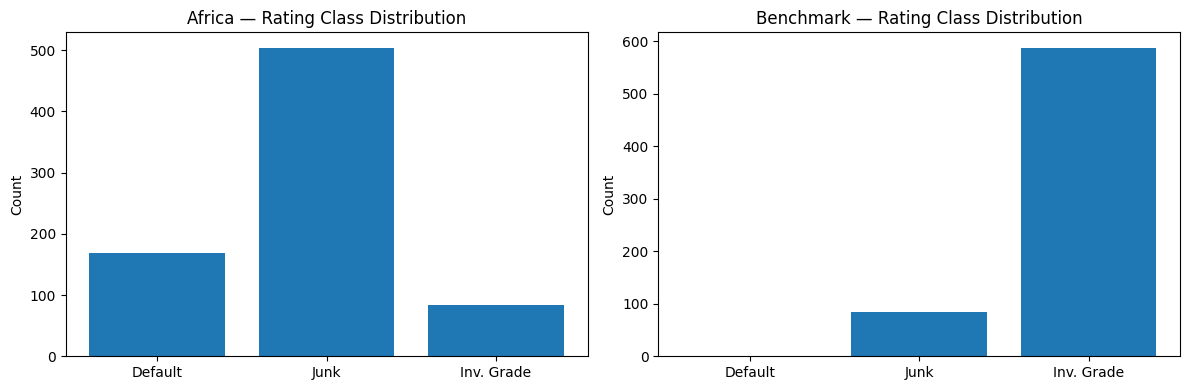

✅ Plot saved.


In [24]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PROC = Path("data/processed")
PROC.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Load the real feature matrix you already created
# --------------------------------------------------
work_df = pd.read_csv(PROC / "feature_matrix_real.csv", parse_dates=["date"])
print("Loaded real feature matrix:", work_df.shape)

work_df = work_df.sort_values(["country", "date"]).reset_index(drop=True)

# --------------------------------------------------
# Rebuild target safely
# --------------------------------------------------
if "future_class" not in work_df.columns:
    work_df["future_class"] = work_df.groupby("country")["current_class"].shift(-1)

work_df["future_class"] = work_df["future_class"].fillna(work_df["current_class"])
work_df["future_class"] = work_df["future_class"].round().astype(int)

if "rating_change" not in work_df.columns:
    work_df["rating_change"] = work_df["future_class"] - work_df["current_class"]

# --------------------------------------------------
# Ensure required base columns exist
# --------------------------------------------------
for col in [
    "S_CB", "S_MKT", "yield_10y", "delta_bond", "delta_fx",
    "inflation", "gdp_growth", "debt_gdp", "reserves_months"
]:
    if col not in work_df.columns:
        work_df[col] = 0.0

work_df["S_CB"] = work_df["S_CB"].fillna(0.0)
work_df["S_MKT"] = work_df["S_MKT"].fillna(0.0)

# --------------------------------------------------
# Rolling features
# --------------------------------------------------
work_df["S_CB_3m"] = work_df.groupby("country")["S_CB"].transform(lambda s: s.rolling(3, min_periods=1).mean())
work_df["S_MKT_3m"] = work_df.groupby("country")["S_MKT"].transform(lambda s: s.rolling(3, min_periods=1).mean())
work_df["delta_bond_3m"] = work_df.groupby("country")["delta_bond"].transform(lambda s: s.rolling(3, min_periods=1).mean())
work_df["delta_fx_3m"] = work_df.groupby("country")["delta_fx"].transform(lambda s: s.rolling(3, min_periods=1).mean())

# --------------------------------------------------
# Lag features
# --------------------------------------------------
work_df["S_CB_lag1"] = work_df.groupby("country")["S_CB"].shift(1)
work_df["S_CB_lag2"] = work_df.groupby("country")["S_CB"].shift(2)
work_df["S_CB_lag3"] = work_df.groupby("country")["S_CB"].shift(3)

work_df["S_MKT_lag1"] = work_df.groupby("country")["S_MKT"].shift(1)
work_df["S_MKT_lag2"] = work_df.groupby("country")["S_MKT"].shift(2)
work_df["S_MKT_lag3"] = work_df.groupby("country")["S_MKT"].shift(3)

work_df["yield_lag1"] = work_df.groupby("country")["yield_10y"].shift(1)
work_df["yield_lag2"] = work_df.groupby("country")["yield_10y"].shift(2)
work_df["yield_lag3"] = work_df.groupby("country")["yield_10y"].shift(3)

work_df["cls_lag1"] = work_df.groupby("country")["current_class"].shift(1)
work_df["cls_lag2"] = work_df.groupby("country")["current_class"].shift(2)
work_df["cls_lag3"] = work_df.groupby("country")["current_class"].shift(3)

# --------------------------------------------------
# Month cyclic encoding
# --------------------------------------------------
work_df["month"] = work_df["date"].dt.month
work_df["month_sin"] = np.sin(2 * np.pi * work_df["month"] / 12)
work_df["month_cos"] = np.cos(2 * np.pi * work_df["month"] / 12)

FEATURE_COLS = [
    "S_CB", "S_MKT", "S_CB_3m", "S_MKT_3m",
    "delta_bond", "delta_fx", "delta_bond_3m", "delta_fx_3m",
    "yield_10y", "inflation", "gdp_growth", "debt_gdp", "reserves_months",
    "S_CB_lag1", "S_CB_lag2", "S_CB_lag3",
    "S_MKT_lag1", "S_MKT_lag2", "S_MKT_lag3",
    "yield_lag1", "yield_lag2", "yield_lag3",
    "cls_lag1", "cls_lag2", "cls_lag3",
    "month_sin", "month_cos"
]

# Fill lag NaNs
for col in FEATURE_COLS:
    work_df[col] = work_df.groupby("country")[col].transform(lambda s: s.ffill().bfill())
    if work_df[col].isna().any():
        work_df[col] = work_df[col].fillna(work_df[col].median())

# --------------------------------------------------
# Final model-ready table
# --------------------------------------------------
model_df = work_df[["country", "date", "region", "future_class"] + FEATURE_COLS].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)

for col in FEATURE_COLS:
    if model_df[col].isna().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

model_df["future_class"] = model_df["future_class"].astype(int)

model_df.to_csv(PROC / "model_ready_features.csv", index=False)

print(f"✅ Saved: {PROC/'model_ready_features.csv'}")
print(f"Shape: {model_df.shape}")
print("\nClass distribution:")
print(model_df["future_class"].value_counts().sort_index().rename({0: "Default", 1: "Junk", 2: "Investment Grade"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, region in zip(axes, ["Africa", "Benchmark"]):
    sub = model_df[model_df["region"] == region]["future_class"].value_counts().sort_index()
    sub = sub.reindex([0, 1, 2], fill_value=0)
    ax.bar(["Default", "Junk", "Inv. Grade"], sub.values)
    ax.set_title(f"{region} — Rating Class Distribution")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(PROC / "class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Plot saved.")

# for downstream training cells
df = model_df.copy()

## 4. Correlation Heatmap — Features vs Target

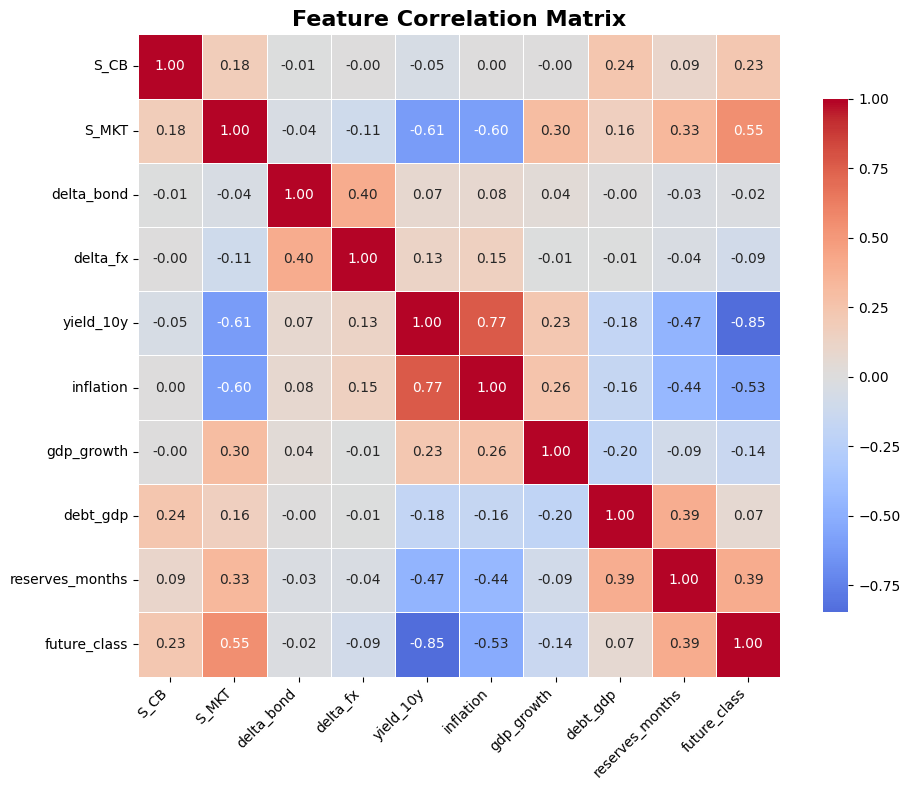

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

core_features = [
    'S_CB','S_MKT','delta_bond','delta_fx','yield_10y',
    'inflation','gdp_growth','debt_gdp','reserves_months','future_class'
]

corr = df[core_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Feature Correlation Matrix", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(PROC/'correlation_heatmap.png', dpi=150)
plt.show()